# DreamLens feature visualization API — PyTorch tutorial

This notebook demonstrates the native PyTorch `dreamlens.features_visualizations` API using normal package imports. Every model, objective, optimization, and result step is visible directly in the notebook cells.

The example maximizes ImageNet class **96 (Toucan)** in a pretrained torchvision ResNet18. It runs the full 1024-step Xplique-style FFT optimization and saves the final canvas, a display-sized image, and the optimization trajectory.

Install the project once from the repository root before opening the notebook:

```bash
pip install -e ".[examples]"
```

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms.functional import to_pil_image

from dreamlens.features_visualizations import Objective, optimize

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
OUTPUT_DIR = ROOT / 'results' / 'feature_visualization_getting_started_pytorch'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 17
torch.manual_seed(SEED)
torch.set_num_threads(min(11, torch.get_num_threads()))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cpu


## 1. API overview

`Objective` describes what the generated image should maximize. The available constructors are:

| Constructor | Target |
|---|---|
| `Objective.neuron(model, layer, ids)` | Flattened neurons or output logits |
| `Objective.channel(model, layer, ids)` | Feature-map channels on NCHW activations |
| `Objective.layer(model, layer)` | Mean or magnitude of a complete layer |
| `Objective.direction(model, layer, vectors)` | User-provided activation directions |

Objectives support `+`, `-`, and scalar multiplication. Multiple target alternatives form a Cartesian product, producing one optimized image for each objective combination.

`optimize(objective, ...)` performs gradient ascent on pixels or Fourier coefficients and returns `(checkpoints, objective_names)`. Each checkpoint is an NCHW tensor shaped `[number_of_objectives, channels, canvas_height, canvas_width]`.

## 2. Load a torchvision model

Feature visualization optimizes the model input, so the model is frozen and kept in evaluation mode. Torchvision classifiers expect ImageNet normalization. The differentiable `preprocess` callback applies it after DreamLens transformations and resize, immediately before model inference.

In [2]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights).to(DEVICE).eval()

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def imagenet_preprocess(images):
    mean = images.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = images.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return (images - mean) / std

TARGET_CLASS = 96
print(TARGET_CLASS, weights.meta['categories'][TARGET_CLASS])

96 toucan


## 3. Define the objective

ResNet18's `fc` module emits 1000 ImageNet logits. `Objective.neuron` flattens the selected module output and maximizes neuron 96. PyTorch modules do not carry input-size metadata, so the objective explicitly declares `(channels, height, width) = (3, 224, 224)`.

In [3]:
objective = Objective.neuron(
    model=model,
    layer='fc',
    neurons_ids=TARGET_CLASS,
    input_shape=(3, 224, 224),
)

print('objective combinations:', objective.num_combinations)

objective combinations: 1


## 4. Run feature visualization

Important arguments:

- `use_fft=True`: optimize Fourier coefficients instead of raw pixels.
- `fft_decay=0.85`: suppress excessive high-frequency energy.
- `transformations='standard'`: use Xplique-compatible padding, jitter, scaling, blur, and flips.
- `custom_shape=(512, 512)`: optimize a 512-pixel canvas while the model still receives 224×224 inputs.
- `preprocess=imagenet_preprocess`: preserve the model's expected input distribution.
- `save_every=128`: retain intermediate image tensors without interrupting optimization.

The optimizer minimizes internally negated scores, which is equivalent to gradient ascent on the requested feature.

In [4]:
STEPS = 1024
SAVE_EVERY = 128

def report_progress(step, total):
    if step == 1 or step == total or step % 64 == 0:
        print(f'step {step:4d}/{total}')

checkpoints, objective_names = optimize(
    objective=objective,
    nb_steps=STEPS,
    optimizer=lambda parameters: torch.optim.Adam(
        parameters, lr=0.05, eps=1e-7
    ),
    use_fft=True,
    fft_decay=0.85,
    std=0.01,
    values_range=(0, 1),
    transformations='standard',
    custom_shape=(512, 512),
    save_every=SAVE_EVERY,
    preprocess=imagenet_preprocess,
    device=DEVICE,
    progress_callback=report_progress,
)

print('objective names:', objective_names)
print('saved checkpoints:', len(checkpoints))
print('checkpoint shape:', tuple(checkpoints[-1].shape))

step    1/1024


step   64/1024


step  128/1024


step  192/1024


step  256/1024


...

step  768/1024


step  832/1024


step  896/1024


step  960/1024


step 1024/1024
objective names: ['Neuron#fc_96']
saved checkpoints: 8
checkpoint shape: (1, 3, 512, 512)


## 5. Save and inspect results

`checkpoints[-1][0]` selects the final checkpoint and its first objective image. The raw 512×512 tensor is the reproducible optimization output; the 224×224 copy is only an antialiased display version.

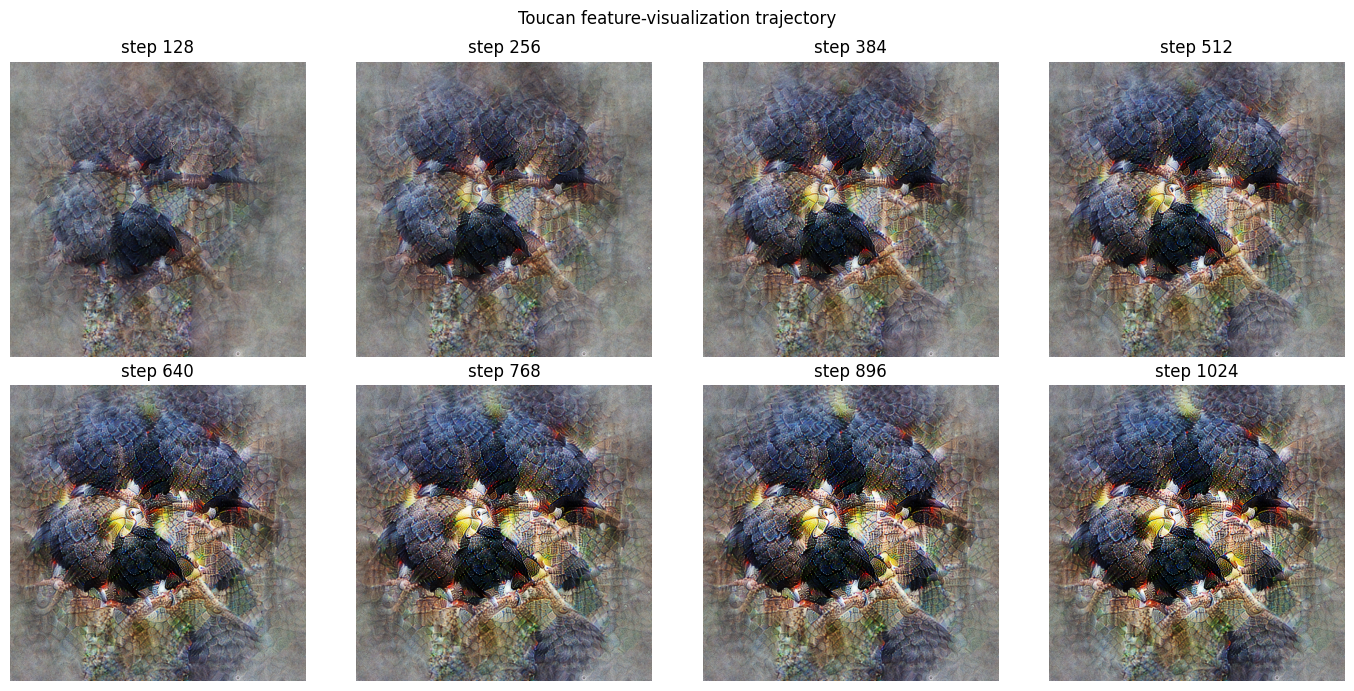

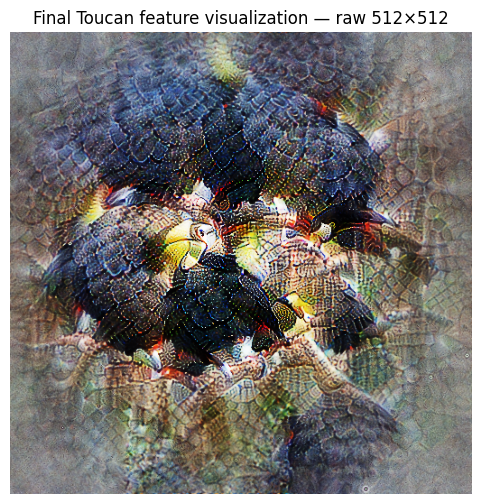

/Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/toucan_raw_512.png
/Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/toucan_display_224.png
/Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/toucan_trajectory.png


In [5]:
final_tensor = checkpoints[-1][0].detach().cpu().clamp(0, 1)
raw_image = to_pil_image(final_tensor)
display_image = raw_image.resize((224, 224), Image.Resampling.LANCZOS)

raw_path = OUTPUT_DIR / 'toucan_raw_512.png'
display_path = OUTPUT_DIR / 'toucan_display_224.png'
trajectory_path = OUTPUT_DIR / 'toucan_trajectory.png'
raw_image.save(raw_path)
display_image.save(display_path)

columns = 4
rows = math.ceil(len(checkpoints) / columns)
figure, axes = plt.subplots(rows, columns, figsize=(14, 7))
for index, (axis, checkpoint) in enumerate(zip(axes.flat, checkpoints)):
    axis.imshow(to_pil_image(checkpoint[0].detach().cpu().clamp(0, 1)))
    axis.set_title(f'step {(index + 1) * SAVE_EVERY}')
    axis.axis('off')
for axis in axes.flat[len(checkpoints):]:
    axis.axis('off')
figure.suptitle('Toucan feature-visualization trajectory')
figure.tight_layout()
figure.savefig(trajectory_path, dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title('Final Toucan feature visualization — raw 512×512')
plt.axis('off')
plt.show()

print(raw_path)
print(display_path)
print(trajectory_path)

## 6. Other supported objectives

The same `optimize` call works with different objectives:

```python
# One image per selected channel
channels = Objective.channel(
    model, 'layer4.1.conv2', [8, 64, 128], input_shape=(3, 224, 224)
)

# Maximize the magnitude of a whole layer
layer = Objective.layer(
    model, 'layer3.1.conv2', reducer='magnitude', input_shape=(3, 224, 224)
)

# Combine targets; alternatives form a Cartesian product
combined = channels + 0.25 * layer

images, names = optimize(
    combined, nb_steps=512, custom_shape=(512, 512),
    preprocess=imagenet_preprocess, device=DEVICE
)
```

`Objective.direction` accepts activation tensors representing desired directions. `maco(...)` is available for magnitude-constrained phase optimization. Transformations, regularizers, Fourier helpers, and loss functions are also exported from `dreamlens.features_visualizations`.